# Classification of Celestial Objects (SLOAN DIGITAL SKY SURVEY DR14)

La **Sloan Digital Sky Survey (SDSS)** rappresenta uno dei più grandi e ambiziosi progetti di mappatura cosmica mai intrapresi. 

A differenza delle osservazioni astronomiche tradizionali, spesso focalizzate su singoli oggetti o piccole regioni, la SDSS è stata concepita per effettuare un vero e proprio "censimento dell'Universo": il progetto conta, misura e classifica centinaia di milioni di oggetti celesti con l'obiettivo di realizzare la mappa tridimensionale del cosmo più dettagliata mai prodotta. 


### Obiettivi Scientifici Primari
Lo scopo fondamentale della SDSS è rispondere ad alcune delle domande più profonde dell'astrofisica, prima fra tutte: *com'è fatto l'universo su larga scala e come si è evoluto?* . 

Per farlo, si concentra sui seguenti obiettivi chiave:

* **Mappare la "Rete Cosmica"** : la SDSS ha rivelato che le galassie non sono sparse casualmente nello spazio, ma si dispongono in una struttura simile a una spugna o una rete (da qui il nome "rete cosmica") fatta di enormi filamenti di galassie che circondano vasti vuoti quasi privi di materia. La mappatura di questa struttura è fondamentale per comprendere la dinamica evolutiva dal Big Bang a oggi.

* **Capire la Materia Oscura** : più del 90% della materia dell'universo è "oscura", cioè invisibile, ma dall'osservazione della distribuzione e del movimento delle galassie, che costituiscono la materia visibile, si può dedurre dove si trova la materia oscura e quale ruolo ha avuto nella formazione della rete cosmica.

* **Studiare l'evoluzione delle Galassie** : raccogliendo milioni di dati, la SDSS permette lo studio delle proprietà delle galassie (morfologia, tasso di formazione stellare, composizione chimica), aiutando a capire perchè ne esistano diversi tipi e come si sono formate ed evolute nel tempo.

* **Studiare la Via Lattea** : l'indagine mappa in dettaglio la struttura, la cinematica e la composizione chimica della nostra galassia, la Via Lattea, fornendo indizi sulla sua storia di formazione.

* **Trovare Quasar** : la SDSS ha identificato centinaia di migliaia di Quasar (nuclei galattici super luminosi alimentati da buchi neri supermassicci), che sono così distanti da permetterci di sondare l'universo primordiale.


### Come funziona la SDSS?
Per costruire tale mappa tridimensinale, la SDSS impiega una strategia osservativa a due fasi, condotta principalmente presso l'Osservatorio di Apache Point (New Mexico) tramite un telescopio dedicato.

1. **Imaging** : lo scopo di questa prima fase è la creazione della mappa 2D che funge da "catalogo digitale" per l'intero universo. In particolare, si misurano con precisione le quattro proprietà fondamentali degli oggetti celesti: *posizione*, *luminosità*, *colore*, *morfologia* (ossia la forma: puntiforme come una stella e un quasar od oggetto esteso come una galassia). Il cuore di questo sistema è l'utilizzo di una grande camera digitale avanzata che utilizza **cinque filtri fotometrici (u, g, r, i, z)** che isolano specifiche finestre di luce, permettendo alla camera di scattare cinque immagini separate dello stesso pezzo di cielo, una per ogni "colore".
Invece di puntare il telescopio, scattare una foto, e poi muoversi (un processo lento), la SDSS ha usato una tecnica chiamata "drift scanning" (scansione a inseguimento) con la quale il telescopio viene puntato su una striscia di cielo e "congelato", è la rotazione stessa della Terra che fa "scorrere" il cielo attraverso il campo visivo della camera. I sensori digitali (CCD) leggono i dati alla stessa velocità con cui il cielo si muove, costruendo un'immagine digitale continua, lunga e ininterrotta, come uno scanner che passa sopra un documento.

2. **Spettroscopia** : in questa fase la mappa 2D si trasforma in un universo 3D, analizzando la natura fisica degli oggetti. In particolare, si cattura lo spettro di un oggetto (scomponendo la sua luce nei colori che la compongono), la cui analisi fornisce i seguenti risultati cruciali: *la natura* dell'oggetto (ossia se è una stella, galasia o quasar), le sue *proprietà fisiche* (composizione chimica, età, temperatura) e la *distanza* (che si calcola mediante il **redshift**, ossia il fenomeno per cui la luce proveniente da un oggetto celeste lontano appare spostata verso l'estremità rossa dello spettro visibile, più un oggetto è lontano e maggiore sarà il suo redshift); quest'ultimo aggiunge l'asse z alla mappa 2D rendendola tridimensionale.



Il presente paper mira a condurre un'analisi comparativa delle performance dei seguenti modelli di classificazione: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree e Random Forest, che si occuperanno della distinzione gli oggetti celesti nelle tre categorie fondamentali: Stelle (STAR), Galassie (GALAXY) e Quasar(QSO).


# Exploratory Data Analysis

## Data Understanding
Il dataset oggetto di analisi è composto da diecimila osservazioni (righe) e 18 variabili (colonne), estratte dal database pubblico della Sloan Digital Sky Survey (SDSS Release 14 del 2017).
Ogni riga rappresenta un singolo oggetto celeste osservato, mentre le colonne contengono le misurazioni fisiche e i metadati tecnici associati a quella osservazione.

Si è iniziata l'analisi importando tutte le librerie di interesse utilizzate nel corso dell'analisi e importando il dataset per visualizzarlo:


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA


In [2]:

data=pd.read_csv('Skyserver_SQL2_27_2018 6_51_39 PM.csv')
display(data)

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1.237650e+18,131.316413,51.539547,18.81777,17.47053,16.91508,16.68305,16.50570,1345,301,3,161,5.033450e+17,GALAXY,0.027583,447,51877,246
9996,1.237650e+18,131.306083,51.671341,18.27255,17.43849,17.07692,16.71661,16.69897,1345,301,3,162,5.033400e+17,GALAXY,0.117772,447,51877,228
9997,1.237650e+18,131.552562,51.666986,18.75818,17.77784,17.51872,17.43302,17.42048,1345,301,3,162,8.222620e+18,STAR,-0.000402,7303,57013,622
9998,1.237650e+18,131.477151,51.753068,18.88287,17.91068,17.53152,17.36284,17.13988,1345,301,3,163,5.033400e+17,GALAXY,0.014019,447,51877,229


### Gruppo 1: Identificatori
Identificano in modo univoco gli oggetti celesti ma non sono legate alle loro proprietà fisiche.

* **objid** : sta per "Object ID" ed è l'identificatore univoco per qualsiasi oggetto identificato dalla camera nella fase di imaging ed è associato ai dati di posizione (*ra, dec*) e luminosità (*u, g, r, i, z*).

* **specobjid** : sta per "Spectroscopic Object ID" ed è l'identificatore per lo spettro unico rilevato dall'indagine spettroscopica dunque è associato ai dati di classificazione (*STAR, GALAXY, QSO*) e distanza (*redshift*).


### Gruppo 2: Posizione
Queste colonne indicano la posizione dell'oggetto nel cielo.
* **ra** : sta per "Right Ascension" ed è la *longitudine* del cielo, è misurata in gradi e dice al telescopio dove puntare in direzione Est-Ovest lungo l'equatore celeste.

* **dec** : sta per "Declination" ed è la *latitudine* del cielo, è misurata in gradi e dice al telescopio dove puntare in direzione Nord-Sud.


### Gruppo 3: Caratteristiche Fisiche
* **redshift** : è la variabile che misura l'effetto doppler della luce, in particolare, se il suo valore è vicino allo zero, allora si è in presenza di una *stella*, se è positivo siamo in presenza di una *galassia* (più lontane da noi) ma se il loro valore è estremamente elevato allora si è in presenza di un *quasar* (siccome sono molto lontani da noi e si allontanano anche velocemente).

* **u, g, r, i, z** : queste misurano la luminosità dell'oggetto e corrispondono rispettivamente a : *Ultraviolet, Green, Red, Infrared (infrarosso Vicino e Lontano)*.


### Gruppo 4: Classificazione
Costituisce la variabile target di questo progetto.
* **class** : è la classificazione dell'oggetto in *STAR*, un oggetto interno alla nostra galassia; *GALAXY*, un sistema di miliardi di stelle, gas e polveri, esterno alla nostra galassia; *QSO*, oggetto incredibilmente luminoso in quanto sta attivamente "divorando" gas e stelle (buco nero supermassiccio).


### Gruppo 5: Dati della Misurazione
Descrivono come, quando e con quale pezzo di equipaggiamento è stata effettuata la misurazione; sono fondamentali per gli astronomi ma non descrivono l'oggetto celeste.

* **run** : è l'ID di una specifica scansione del cielo.

* **rerun** : ID della versione di rielaborazione software dei dati.

* **camcol** : indica quale delle 6 colonne della camera ha ripreso l'oggetto.

* **field** : ID di uno scatto della camera.

* **plate** : ID della piastra utilizzato dagli scienziati per ottenere lo spettro di un corpo celeste.

* **mjd** : formato standard utilizzato per registrare la data e l'ora esatta in cui è stato preso lo spettro.

* **fiberid** : sulla piastra utilizzata per prendere lo spettro si praticano dei fori ai quali si collega una fibra ottica responsabile di portare la luce allo spettrografo, questo è l'ID della fibra che ha catturato la luce di un dato oggetto.

## Data Cleaning and Descriptive Statistics


Prima di procedere con l'analisi esplorativa e il modeling, si è innanzitutto sottoposto il dataset a una rigorosa fase di pulizia. L'integrità dei dati è un prerequisito fondamentale per poter applicare qualsiasi tipo di modello: l'utilizzo di dati "rumorosi", incompleti o non opportunamente scalati porterebbe inevitabilmente a risultati inaffidabili e fuorvianti.

Le operazioni di pulizia comprendono: la verifica di completezza del dataset, la rimozione di duplicati, la gestione di eventuali valori mancanti e la standardizzazione del formato dei dati.

*Perchè questa fase è importante?*
1. **Qualità delle decisioni**: se i dati di input sono errati o distorti, qualsiasi *insight* derivato o classificazione effettuata dal modello risulterà intrinsecamente fallace;
   
2. **Prevenzione degli errori**: Identificare le anomalie in questa fase preliminare permette di evitare errori a cascata nelle fasi successive, risparmiando risorse computazionali e tempo di debug;

3. **Affidabilità**: rimuovere le incongruenze e rumore rende il dataset più robusto e affidabile;

4. **Efficienza dell'analisi**: lavorare su un dataset pulito consente di concentrare gli sforzi solo sull'interpretazione dei fenomeni fisici e sull'ottimizzazione degli algoritmi, piuttosto che sulla correzione degli errori.


### Feature Selection
Il primo passo ha riguardato la Feature Selection, ovvero la rimozione delle variabili non informative. Un dataset ad alta dimensionalità contenente dati irrilevanti può infatti degradare le prestazioni dei modelli e aumentare il rischio di overfitting.

In questa sezione si è proceduto all'eliminazione di due gruppi di variabili: le variabili appartenenti al gruppo 1, siccome non possiedono alcun potere predittivo sulla natura fisica dell'oggetto e sono stati sostituiti dall'indice progressivo delle righe del dataset; e le variabili appartenenti al gruppo 5, siccome descrivono le configurazioni tecniche cel telescopio e la data dell'osservazione, queste informazioni sono solo "rumore" rispetto all'obiettivo ultimo del'analisi.

In questo modo si permette ai modelli di concentrarsi esclusivamente sul segnale utile, migliorando sia la velocità di addestramento che la capacità di generalizzazione.


In [3]:
data.drop(['objid', 'specobjid', 'run', 'rerun', 'camcol', 'field', 'plate', 'mjd', 'fiberid'], axis=1, inplace=True)
display(data)

,ra,dec,u,g,r,i,z,class,redshift
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590
...,...,...,...,...,...,...,...,...,...
9995,131.316413,51.539547,18.81777,17.47053,16.91508,16.68305,16.50570,GALAXY,0.027583
9996,131.306083,51.671341,18.27255,17.43849,17.07692,16.71661,16.69897,GALAXY,0.117772
9997,131.552562,51.666986,18.75818,17.77784,17.51872,17.43302,17.42048,STAR,-0.000402
9998,131.477151,51.753068,18.88287,17.91068,17.53152,17.36284,17.13988,GALAXY,0.014019


Il risultato dell'operazione è che il dataset originale è stato ridotto da 18 a 9 colonne, le cui variabili corrispondenti costituiscono il nucleo fisico dell'informazione.

Si procede nel verificare la presenza di missing values e duplicati:

In [4]:
dataset_null=data.isnull()
print(dataset_null)

         ra    dec      u      g      r      i      z  class  redshift
0     False  False  False  False  False  False  False  False     False
1     False  False  False  False  False  False  False  False     False
2     False  False  False  False  False  False  False  False     False
3     False  False  False  False  False  False  False  False     False
4     False  False  False  False  False  False  False  False     False
...     ...    ...    ...    ...    ...    ...    ...    ...       ...
9995  False  False  False  False  False  False  False  False     False
9996  False  False  False  False  False  False  False  False     False
9997  False  False  False  False  False  False  False  False     False
9998  False  False  False  False  False  False  False  False     False
9999  False  False  False  False  False  False  False  False     False

[10000 rows x 9 columns]


Il comando restituisce una maschera booleana (dove *True* indica un valore mancante e *False* un valore presente), però l'ispezione visiva di tale risultato risulta difficile data la dimensione del dataset.

Di conseguenza si è optato per il comando sottostante, che restituisce il conteggio totale dei valori non nulli per ogni variabile e il tipo di dato (Type) corrispondente, che ci permette di verificare che il formato di archiviazione sia coerente con la struttura fisica della misurazione.


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ra        10000 non-null  float64
 1   dec       10000 non-null  float64
 2   u         10000 non-null  float64
 3   g         10000 non-null  float64
 4   r         10000 non-null  float64
 5   i         10000 non-null  float64
 6   z         10000 non-null  float64
 7   class     10000 non-null  str    
 8   redshift  10000 non-null  float64
dtypes: float64(8), str(1)
memory usage: 751.2 KB


In [6]:
print('duplicates:', data.duplicated().sum())

duplicates: 0


\
Si osserva che non vi sono ne valori nulli ne duplicati.


\
L'analisi descrittiva è uno step fondamentale dell'EDA in quanto costituisce il primo vero passaggio analitico volto a trasformare il dato grezzo in informazione.

Lo scopo di questa fase è quello di verificare la coerenza interna del dataset e l'efficacia delle operazioni di pulizia precedenti, inoltre consente anche di acquisire una conoscenza più profonda dei dati in analisi identificando pattern e anomalie.

In [7]:
data.describe() #for numerical type

,ra,dec,u,g,r,i,z,redshift
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,175.529987,14.836148,18.619355,17.371931,16.840963,16.583579,16.422833,0.143726
std,47.783439,25.212207,0.828656,0.945457,1.067764,1.141805,1.203188,0.388774
min,8.235100,-5.382632,12.988970,12.799550,12.431600,11.947210,11.610410,-0.004136
25%,157.370946,-0.539035,18.178035,16.815100,16.173333,15.853705,15.618285,0.000081
50%,180.394514,0.404166,18.853095,17.495135,16.858770,16.554985,16.389945,0.042591
75%,201.547279,35.649397,19.259232,18.010145,17.512675,17.258550,17.141447,0.092579
max,260.884382,68.542265,19.599900,19.918970,24.802040,28.179630,22.833060,5.353854


In [8]:
data['class'].value_counts()

class
GALAXY    4998
STAR      4152
QSO        850
Name: count, dtype: int64

\
In preparazione alla fase successiva, si è proceduto alla separazione strutturale dei dati in due sottoinsiemi distinti:
1. Subset delle Feature Numeriche: è stato isolato un dataframe contente esclusivamente le variabili quantitative.

2. Variabile Target: la variabile categorica è stata isolata in una struttura separata.

In [9]:

data_num=data.drop(['class'], axis=1)
display(data_num)

,ra,dec,u,g,r,i,z,redshift
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,-0.000009
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,-0.000055
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,0.123111
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,-0.000111
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,0.000590
...,...,...,...,...,...,...,...,...
9995,131.316413,51.539547,18.81777,17.47053,16.91508,16.68305,16.50570,0.027583
9996,131.306083,51.671341,18.27255,17.43849,17.07692,16.71661,16.69897,0.117772
9997,131.552562,51.666986,18.75818,17.77784,17.51872,17.43302,17.42048,-0.000402
9998,131.477151,51.753068,18.88287,17.91068,17.53152,17.36284,17.13988,0.014019


In [10]:

data_cat=data['class']
display(data_cat) 
    

0         STAR
1         STAR
2       GALAXY
3         STAR
4         STAR
         ...  
9995    GALAXY
9996    GALAXY
9997      STAR
9998    GALAXY
9999    GALAXY
Name: class, Length: 10000, dtype: str

## Univariate analysis
L'analisi delle singole variabili ha l'obiettivo di identificare le caratteristiche distributive dei dati e rilevare eventuali anomalie (outliers) che potrebbero influenzare negativamente l'addestramento dei modelli.

Dapprima si è costruito un grafico a barre della variabile target, che ha rivelato quanto sia sbilanciato il dataset:

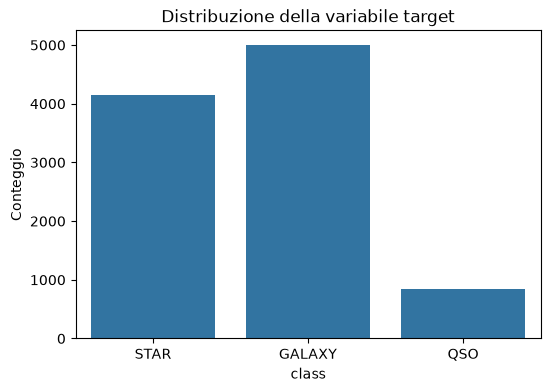

In [11]:
# distribuzione del target
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=data)
plt.title('Distribuzione della variabile target')
plt.ylabel('Conteggio')
plt.show()

Successivamente si sono adoperati istogrammi e Box Plot per visualizzae le distribuzioni dei dati, in particolare il Box Plot è stato d'aiuto per rilevare gli outliers:

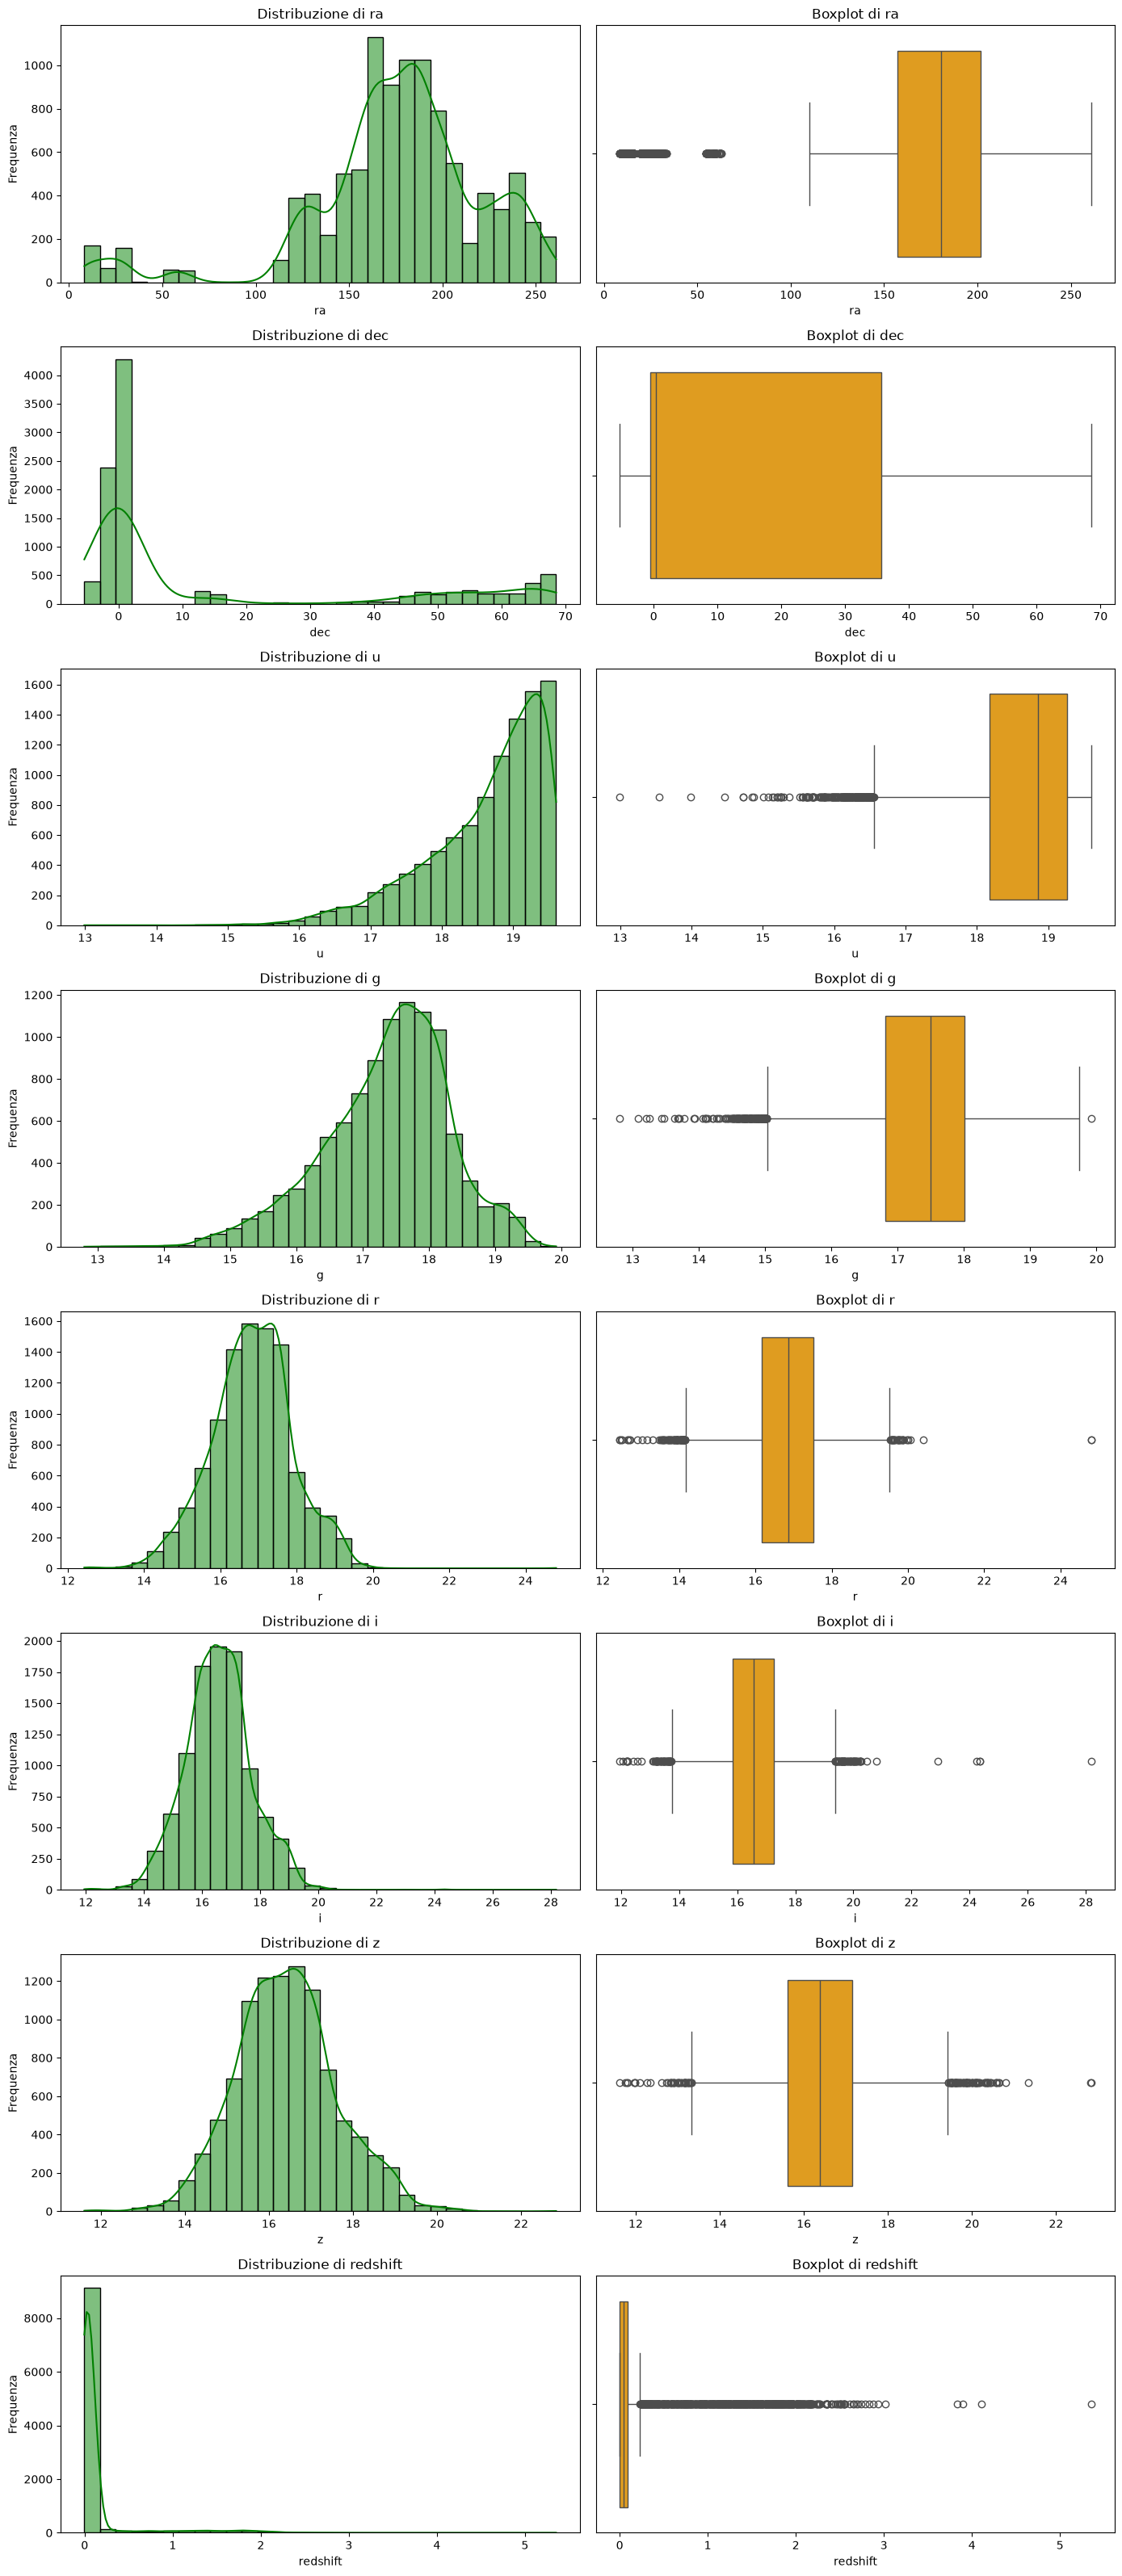

In [12]:
n=8 #numero delle features
fig, axes=plt.subplots(n, 2, figsize=(14, 4*n))

for i, col in enumerate(data_num):
    #faccio l'istogramma a sx
    sns.histplot(data[col], kde=True, bins=30, color='green', ax=axes[i,0])
    axes[i,0].set_title(f'Distribuzione di {col}')
    axes[i,0].set_ylabel('Frequenza')
    
    #faccio il boxplot a dx
    sns.boxplot(x=data[col], ax=axes[i,1], color='orange')
    axes[i,1].set_title(f'Boxplot di {col}')
    

plt.tight_layout()
plt.show()

### Bivariate Analysis

Si è proceduto con un'analisi Bivariata per osservare le interazioni tra le variabili:

<Figure size 1500x1200 with 0 Axes>

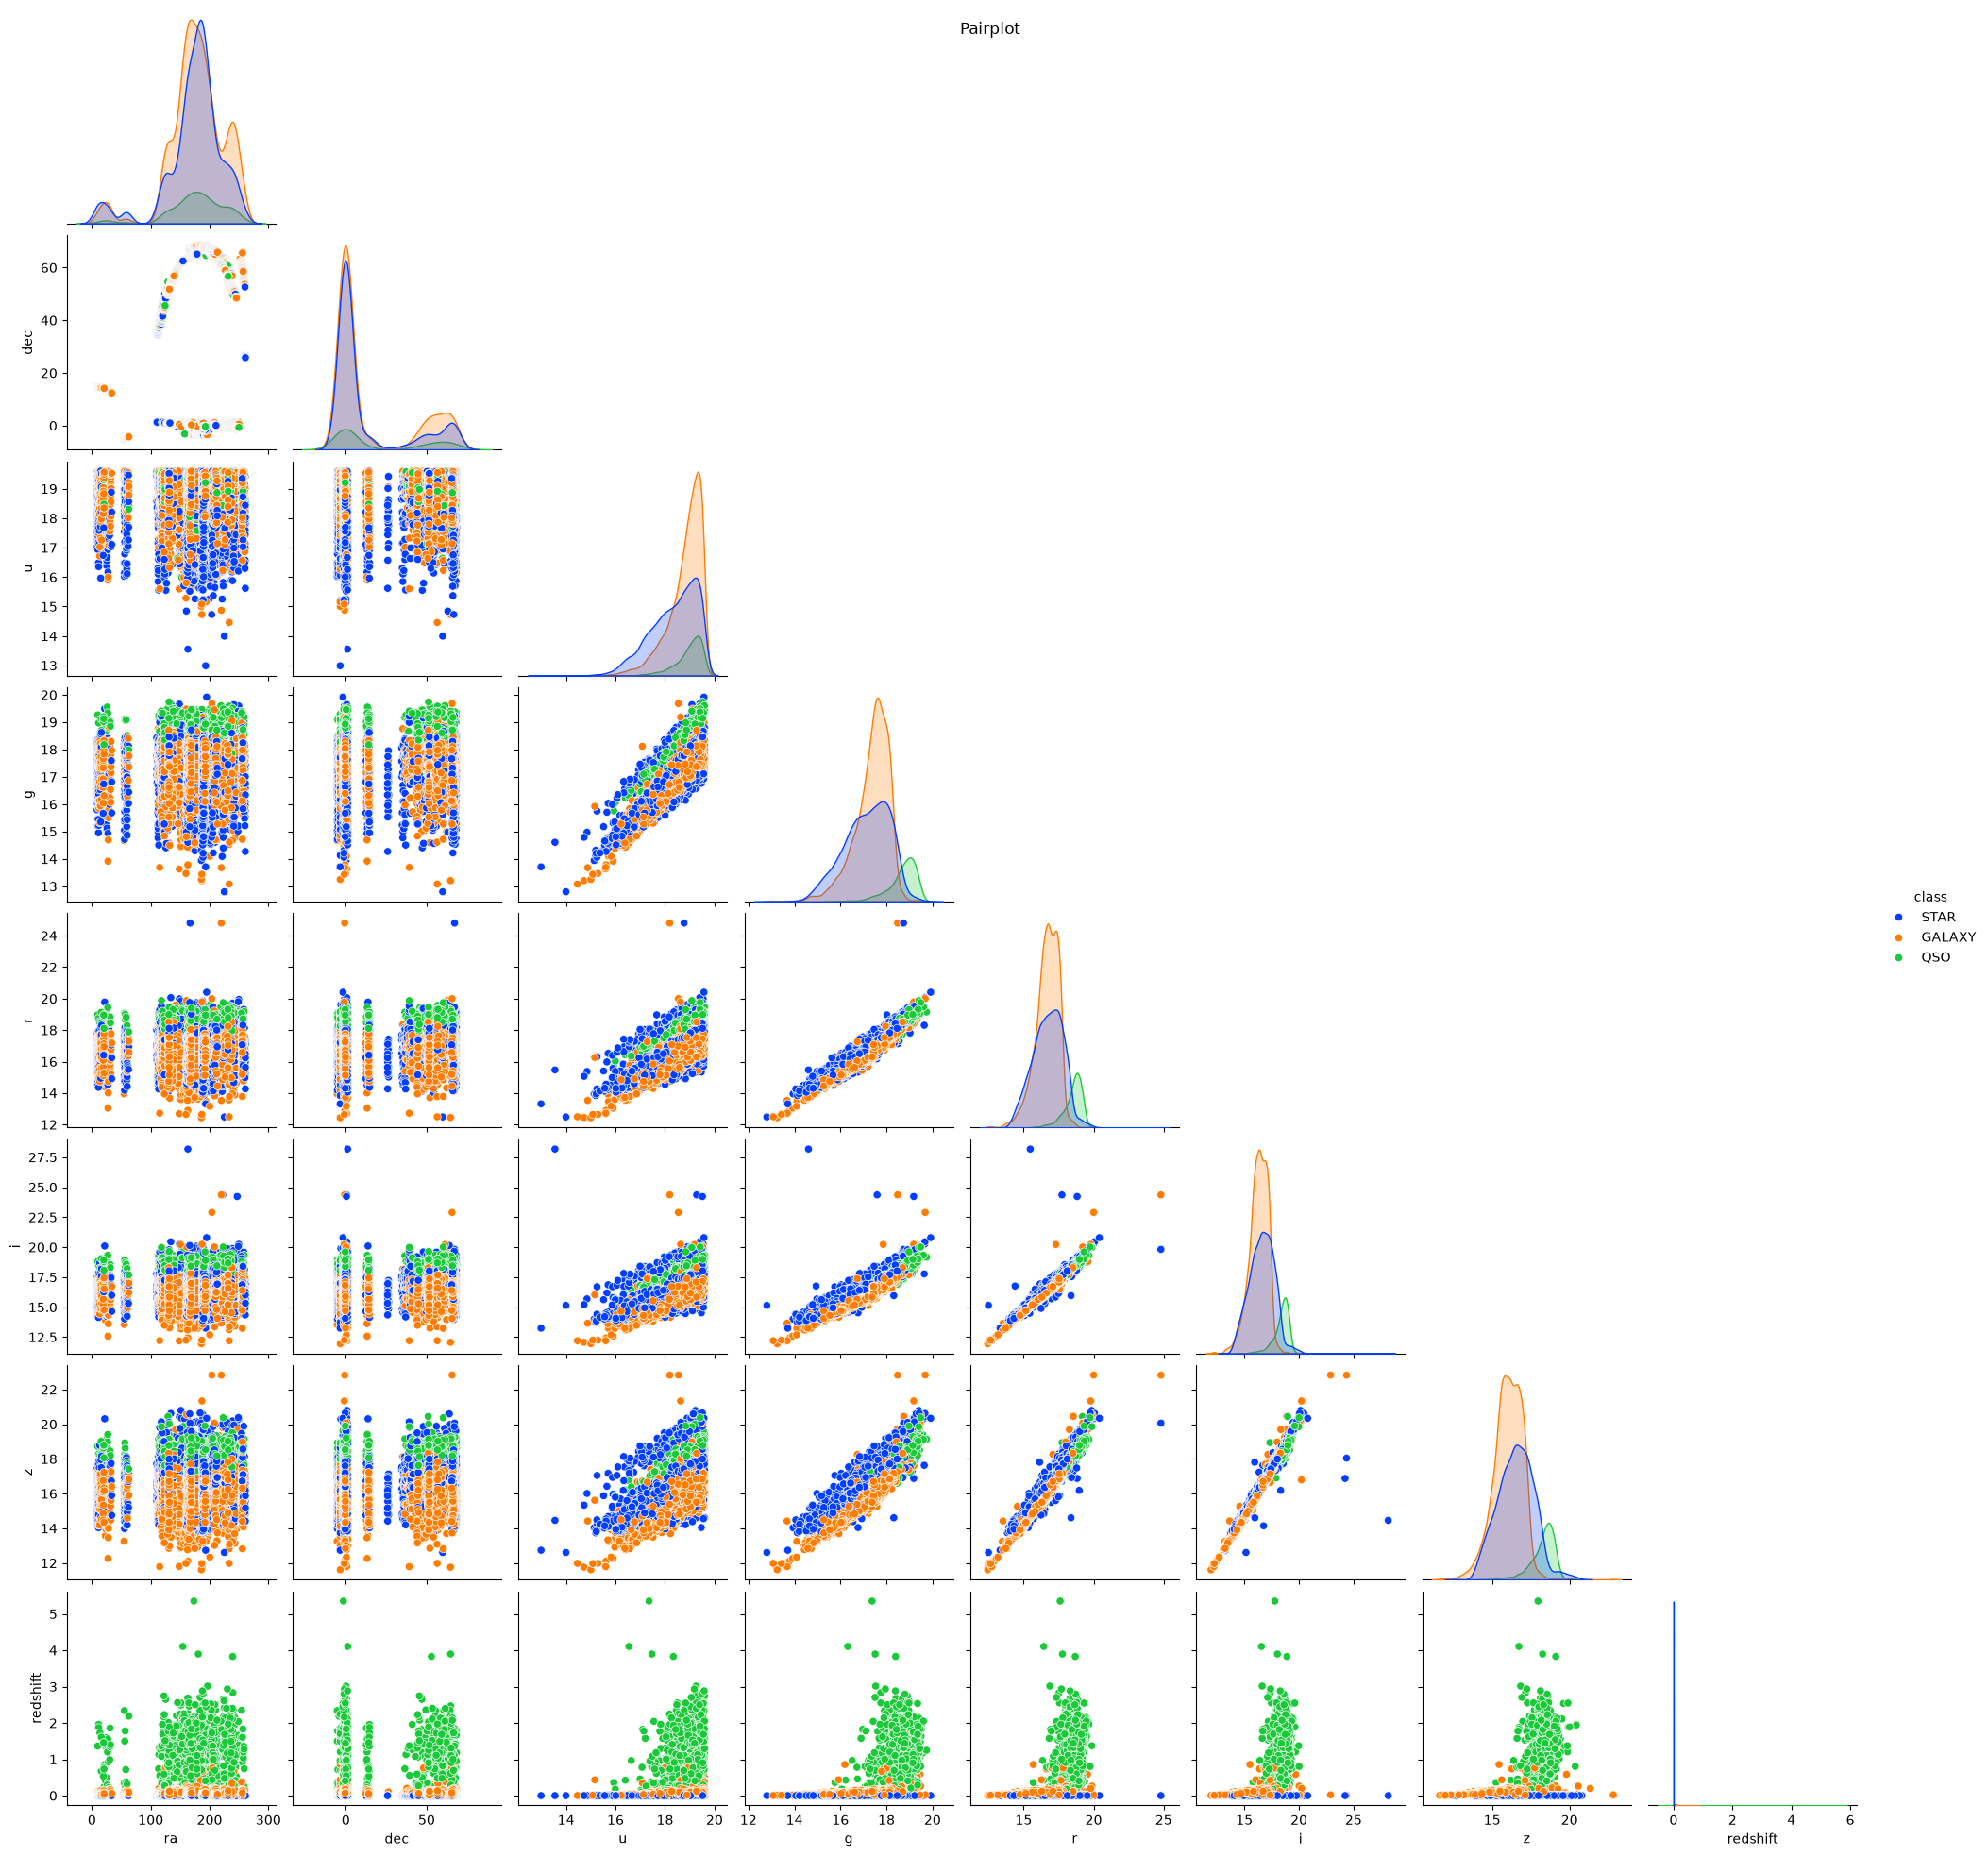

In [13]:
#pairplot
plt.figure(figsize=(15,12))
sns.pairplot(data, hue='class', palette='bright', corner=True, plot_kws=None)
plt.suptitle('Pairplot')
plt.show()

Osservando il primo riquadro in alto a sinistra (Ascensione Retta vs Declinazione), si osservano che le tre classi (stelle, Galassie e Quasar) condividono la stessa distribuzione spaziale, ciò suggerisce che non esistono aree del cielo riservate a una sola classe, ovunque la SDSS punti il telescopio, c'è un'equiprobabilità di osservare una stella, una galassia o un quasar.

Dunque le coordinate *ra* e *dec* non possiedono potere discriminante intrinseco per la classificazione fisica dell'oggetto, questo vuol dire che potrebbero essere escluse dal modello predittivo finale, in quanto la natura di un corpo celeste non dipende dalla sua posizione nella volta celeste.

Osservando l'ultima riga del grafico (Redshift sull'asse X vs altre feature) si chiarisce la natura degli outliers rilevati nel corso dell'analisi univariata, essi infatti non sono errori di misurazione ma corrispondono esclusivamente ai valori assunti dalla classe QSO; inoltre, si può sservare che i Quasar sono geometricamente be separati dalle altre due classi lungo l'asse del redshift, questo sugegrisce che per classificare i quasar basterebbe anche un modello lineare semplice. Al contrario, si osserva che Stelle e Galassie si distribuiscono sullo stesso range di redshift e risultano indistinguibili.

Osservando però l'analisi delle magnitudini, emerge la differenza sottile tra Stelle e Galassie (impossibile da vedere solo col redshift), è proprio questa differenza che permette a modelli non lineari come il Random Forest di operare nella classificazione di Stelle e Galassie, compito in cui un modello lineare semplice fallirebbe a causa della sovrapposizione.

I grafici delle magnitudini mostrano una forte collinearità , in quanto si osservano i punti disporsi lungo una diagonale definita, si osserva dunque una forte correlazione positiva che indica: se un oggetto è luminoso in una banda, lo è tendenzialmente anche nelle altre.

Dunque per concludere:
- il Redshift agisce come filtro primario per separare nettamente i Quasar;
- le relazioni tra gli indici spettrali agiscono come un filtro secondario per districare la sovrapposizione tra Stelle (spettro puntifome e coerente) e Galassie (spettro più complesso e disperso).



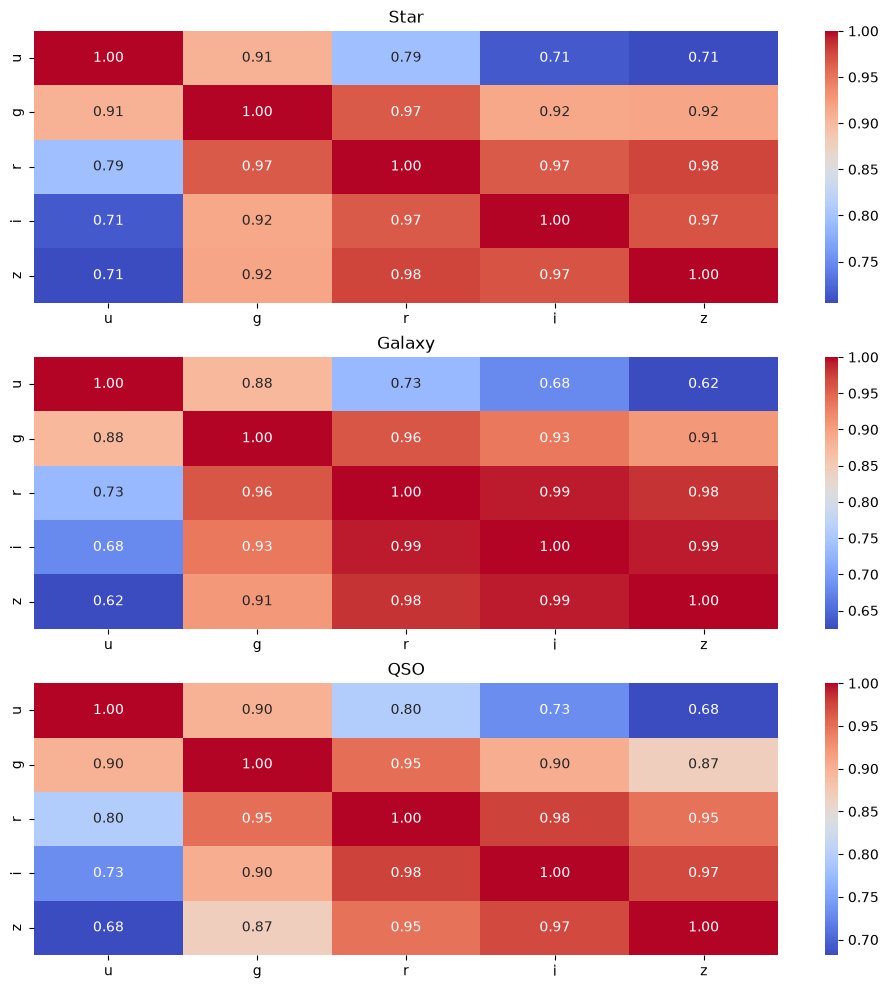

In [14]:
fig, axes= plt.subplots(nrows=3, ncols=1, figsize=(12,12))
ax = sns.heatmap(data[data['class']=='STAR'][['u', 'g', 'r', 'i', 'z']].corr(), ax = axes[0], cmap='coolwarm', annot=True, fmt='.2f')
ax.set_title('Star')
ax = sns.heatmap(data[data['class']=='GALAXY'][['u', 'g', 'r', 'i', 'z']].corr(), ax = axes[1], cmap='coolwarm', annot=True, fmt='.2f')
ax.set_title('Galaxy')
ax = sns.heatmap(data[data['class']=='QSO'][['u', 'g', 'r', 'i', 'z']].corr(), ax = axes[2], cmap='coolwarm', annot=True, fmt='.2f')
ax = ax.set_title('QSO')

Si osserva che la correlazione (dai coefficienti di Pearson) è circa la stessa per ogni classe, dunque le diverse bande spettrali si comportano allo stesso modo per le diverse classi, ciò porta ridondanza informativa, che verrà trattata nella prossima sezione.


Successivamente, si è proceduto alla fase di Data Encoding, un passaggio importantissimo del preprocessing che consiste nella conversione delle variabili categoriche (di tipo testuale) in formato numerico.

Questa trasformazione è un prerequisito tecnico imprescindibile per l'addestramento dei modelli. La maggior parte degli algoritmi di Machine Learning opera su matrici e pertanto richiede input esclusivamente numerici.

Nello specifico del dataset qui in analisi, si è proceduto nella trasformazione della variabile target "class", le cui etichette testuali sono state mappate su valori interi univoci utilizzando la tecnica di *Label Encoding* (GALAXY=0, QSO=1, STAR=2).

In [15]:
le=LabelEncoder()
data['class']=le.fit_transform(data['class'])

Si precisa che il Label Encoding è stato preferito al One-Hot Encoding a causa delle specifiche tecniche della libreria Scikit-learn.

L'implementazione di algoritmi di classificazione, come Random Forest e Decision Tree, richiede che il vettore target *y* passato al metodo *.fit()* sia un array monodimensionale.

### Feature Engineering  
### PCA
L'analisi precedente ha evidenziato una forte multicollinearità tra le cinque bande fotometriche *(u, g, r, i, z)*, si è dunque deciso di intervenire per ridurre la ridondanza del dataset senza perdere contenuto informativo.

Nello specifico, è stata applicata la PCA (Principal Component Analysis), con l'obiettivo di ottenere una rappresentazione dei dati a dimesionalità ridotta. La tecnica è stata applicata in modo selettivo esclusivamente sulle cinque bande fotometriche, portando all'estrazione di due componenti principali, **PC1** e **PC2**, ortogonali tra loro. Matematicamente, ogni componente è una combinazione lineare delle feature originali: i coefficienti di questa combinazione, i **loadings**, indicano quanto ciascuna variabile originale contribuisca alla costruzione della nuova componente.

Oltre a risolvere il problema della multicollinearità, questa riduzione dimensionale offre un significativo vantaggio in termini di **efficienza computazionale**: lavorando su un  numero inferiore di variabili, si riduce la cmplessità di calcolo e si abbattono i tempi necessari per l'addestramento del modello.

In [16]:
#dal pairplot osserviamo che possiamo eliminare ra e dec
data=data.drop(['ra', 'dec'], axis=1)

In [17]:
pca=PCA(n_components=2)
u_g_r_i_z= pca.fit_transform(data[['u','g','r','i','z']])

#update dataframe
data=pd.concat((data,pd.DataFrame(u_g_r_i_z)), axis=1)
data.rename({0:'PCA_1', 1:'PCA_2'}, axis=1, inplace=True)
data.drop(['u','g','r','i','z'], axis=1, inplace=True)
data.head()

,class,redshift,PCA_1,PCA_2
0,2,-0.000009,-1.507202,1.377293
1,2,-0.000055,-0.195758,0.028410
2,0,0.123111,1.297604,0.590023
3,2,-0.000111,-1.446117,-0.566685
4,2,0.000590,-0.849271,-1.287505


Si è poi effettuato lo split dei dati aggiornati:

In [18]:
X=data.drop('class', axis=1)
Y=data['class']
display(X)
print('='*60)
display(Y)

,redshift,PCA_1,PCA_2
0,-0.000009,-1.507202,1.377293
1,-0.000055,-0.195758,0.028410
2,0.123111,1.297604,0.590023
3,-0.000111,-1.446117,-0.566685
4,0.000590,-0.849271,-1.287505
...,...,...,...
9995,0.027583,0.222959,0.134301
9996,0.117772,0.259171,-0.415333
9997,-0.000402,1.480725,-0.388717
9998,0.014019,1.392088,-0.117004


0       2
1       2
2       0
3       2
4       2
       ..
9995    0
9996    0
9997    2
9998    0
9999    0
Name: class, Length: 10000, dtype: int64

\
Si è suddiviso il dataset in due sottoinsiemi disgiunti: il **Training Set**, utilizzato per l'addestramento dei modelli, e il **Test Set**, utilizzato per la valutazione delle performance finali.

La divisione è stata effettuata con il seguente criterio: 70% Training Set e 30% Test Set.

Inoltre, è stato utilizzato il parametro *stratify* per garantire che la proporzione delle tre classi target (Stelle, Galassie e Quasar) rimanesse identica in entrambi i sottoinsiemi, preservando la rappresentatività statistica anche per le classi meno numerose.

In [19]:
#70/30
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

### Feature Scaling
Si è proceduto, poi, con lo *scaling* delle variabili, in particolare si è utilizzato lo **Standard Scaler**, che trasforma la distribuzione di ogni feature in modo che abbia: Media pari a zero e Deviazione Standard pari a 1.

Si precisa che lo Scaler è stato applicato esclusivamente al Training Set, ciò permette di evitare il *Data Leakage*.

In [20]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

## Model Training
Come anticipato in fase introduttiva, lo scopo centrale del progetto è la selezione del miglior classificatore per la distinzione degli oggetti celesti in Stelle, Galassie e Quasar. Per affrontare questo problema di classificazione multiclasse, sono state adottate le seguenti quattro tecniche di modellazione:

### Logistic Regression
La regressione logistica rappresenta l'approccio parametrico standard per modellare la probabilità a posteriori che un'osservazione appartenga a una specifica classe, dati i valori dei predittori. A differenza della regressione lineare, che non è adatta a variabili di risposta di tipo qualitativo poichè potrebbe generare stime di probabilità non ammissibili (negative o superiori all'unità), la regressione logistica adotta una funzione di legame specifica che vincola l'output modellato all'intervallo di probabilità corretto.

Secondo l'approccio frequentista descritto in letteratura, i coefficienti del modello non vegono stimati minimizzando la somma dei quadrati degli errori (RSS), bensì attraverso il metodo della Massima Merosimiglianza (MLE). Questo processo iterativo identifica i parametri che massimizzano la probabilità congiunta di osservare i dati campionari effettivamente raccolti (Likelihood Function).

Poichè il presente studio analizza una variabile risposta con tre categorie, il modello binario standard è stato esteso alla Regressione Logistica Multinomiale. In questo contesto, la generalizzazione della funzione logistica è ottenuta tramite l'applicazione della funzione Softmax. Tale algorito normalizza gli output del modello lineare, trasformandoli in vettori di probabilità la cui somma è pari all'unità, garantendo così una distribuzione di probablità valida su tutte le K classi possibili. La classe predetta corrisponde a quella associata alla probabilità stimata più elevata.

### K-Nearest Neighbors (KNN)
K-Nearest Neighbors è un metodo di classificazione non parametrico che si distingue per l'assenza di assunzioni esplicite sulla forma funzionale della distribuzione dei dati sottostanti. Invece di stimare parametri globali, l'algoritmo opera secondo una logica "memory-based", determinando la classificazione esclusivamente sulla base della struttura locale dei dati nello spazio delle feature.

Il processo decisionale si articola identificando, per ogni nuova osservazione, un isieme di K punti del training set più vicini ad essa, calcolati secondo la distanza Euclidea. La stima della probabilità di appartenenza a una classe è derivata dalla frequenza relativa di tale classe all'interno del vicinato identificato.

Molto importante è la scelta del parametro K (impostato qui di default a 5), che regola direttamente la flessibilità del modello:
* Un valore di K piccolo comporta un modello altamente flessibile con confini di decisione irregolari, minimizzando il bias ma esponendo il modello a un'elevata varianza (rishio di overfitting).
  
* Un valore di K elevato produce dei confini decisionali più levigati e stabili, riducendo la varianza a scapito di un incremento del bias (rischio di underfitting).

### Decision Trees
I Decision Trees operano attraverso una strategia di segmentazione gerarchica dello spazio dei predittori. L'approccio metodologico è definito *top-down* e *greedy* : l'algoritmo procede, partendo dall'intero dataswt, effettuando divisioni binarie successive (recursive binary splitting) con l'obiettivo di massimizzare l'omogeneità dei nodi risultanti.

La selezione della variabile di taglio e del punto di divisione ottimale non si basa sull'errore di classificazione, ritenuto poco sensibile, ma sull'impiego degli indici di purezza statistica come l'indice di Gini o l'Entropia. Tali metriche quantificano il grado di disordine o varianza totale tra le classi all'interno di un nodo specifico; valori bassi di tali indici indicano che il nodo è composto prevalentemente da osservazioni appartenenti alla stessa classe.

Per mitigare la tendenza naturale degli alberi a sovrastimare la complessità dei dati (overfitting), la metodologia prevede una fase di potatura (pruning) basata sulla complessità di costo. Questa tecnica penalizza la dimendione dell'albero, permettendo di selezionare una struttura più parsimoniosa che sacrifichi marginalmente l'accuratezza sul training set per ottenere una migliore capacità di generalizzazione sui dati non osservati.

### Random Forest
Le Random Forest costituiscono una tecnica di *ensemble learning* progettata per perfezionare il metodo del Bagging (Bootstrap Aggregation), riducendo la varianza delle predizioni senza alterarne il bias. Il limite principale del Bagging semplice risiede nella correlazione tra gli alberi generati: in presenza di predittori molto forti, la maggior parte degli alberi prodotti tramite bootstrap tenderà a utilizzare le medesime variabili per le prime divisioni, risultando strutturalmente simili.

Random Forest si occupa della decorrelazione degli stimatori. Durante la costruzione di ciascun albero decisionale, ad ogni divisione del nodo, l'algoritmo è vincolato a considerare solo un sottoinsieme casuale dei predittori disponibili. Questa restrizione stocastica impedisce alle variabili dominanti di monopolizzare la struttura della foresta, garantendo una maggiore diversità tra i singoli alberi.

L'aggregazione delle predizioni di alberi decorrelati (tramite il criterio della maggioranza) produce una stima finale caratterizzata da una varianza significativamente inferirore rispetto ai singoli alberi o al Bagging standard, risultando in una maggiore robustezza e accuratezza predittiva.



### Metriche di Valutazione delle Performance
Per quantificare la capacità predittiva dei modelli di classificazione implementati è necessario valutare la discrepanza tra le classi predette $ \hat{y} $ e le classi reali $ y $. La valutazione si fonda sulla costruzione della **Matrice di Confusione**, da cui derivamo le principali metriche di performance: *Accuratezza, Precisione, Recall e F1-Score*.

**1. Matrici di Confusione**

Una matrice di confusione è una tabella $\mathbf{K} \times \mathbf{K}$ che confronta le classificazioni predette dal modello con le classi osservate nel test set. In particolare gli elementi di matrice sono definiti come **True Positive (TP)**, osservazioni positive classificate correttamente come positive, **True Negatives (TN)**, osservazioni negative classificate orrettamente come negative, **False Positives (FP)**, osservazioni negative classificate erroneamente come positive (Errore di I Tipo), **False Negatives (FN)**, osservazioni positive classificate erroneamente come neghative (Erropre di II Tipo).

**2. Accuratezza**

L'accuratezza rappresenta la metrica di performance più intuitiva e indica il rapporto tra il numero di osservazioni correttamente classificate e il numero totale di osservazioni. Tuttavia, basarsi esclusivamente sull'accuratezza può essere fuorviante, soprattutto in presenza di dataset sbilanciati (come nel caso in esame). 



**3. Precisione** 

La precisione è il rapporto tra le osservazioni positive correttamente previste (TP) e il totale delle osservazioni previste come positive (TP+FP), dunque quantifica l'affidabilità del classificatore nel predire la classe positiva ne consegue che un'alta precisione implica un basso tasso di falsi positivi.

**3.Recall (Sensibilità)**

Il Recall, noto anche come *Sensibilità* o *True Positive Rate*, è il rapporto tra le osservazioni positive correttamente previste (TP) e il totale delle osservazioni effettivamente positive (TP+FN), in particolare, misura le capacità del modello di individuare tutte le istanze positive presenti nel dataset. Precisione e Recall sono particolarmente rilevanti in scenari caratterizzati da uno squilibrio tra le classi (come in questo caso). 


**4.F1-Score**

L'F1-Score è la media armonica (pesata) tra Precisione e Recall. A differenza della media aritmetica, la media armonica penalizza fortemente i valori estremi. Pertanto, l'F1-Score è una metrica robusta per dataset sbilanciati, in quanto raggiunge un valore elevato solo se sia Precisione che Recall sono elevate simultaneamente.



Per Valutare la performance del modello sul test set è stata adoperata una **Stratified Cross-Validation** data la natura sbilanciata del dataset. La stratificazione assicura che la classe minoritaria sia equamente rappresentata in ogni fase di test.


Inizio addestramento con Cross-Validation e Test
Modello: Logistic Regression (Softmax)
Accuratezza CV (5-fold): 0.9610 (+/- 0.0019)
Accuratezza Test Set: 0.9600
------------------------------------------------------------
              precision    recall  f1-score   support

      GALAXY       0.98      0.94      0.96      1499
         QSO       0.98      0.87      0.92       255
        STAR       0.94      1.00      0.97      1246

    accuracy                           0.96      3000
   macro avg       0.96      0.94      0.95      3000
weighted avg       0.96      0.96      0.96      3000

Modello: Logistic Regression (OvR)
Accuratezza CV (5-fold): 0.9211 (+/- 0.0028)
Accuratezza Test Set: 0.9197
------------------------------------------------------------
              precision    recall  f1-score   support

      GALAXY       0.95      0.88      0.92      1499
         QSO       0.93      0.97      0.95       255
        STAR       0.89      0.95      0.92      1246

    acc

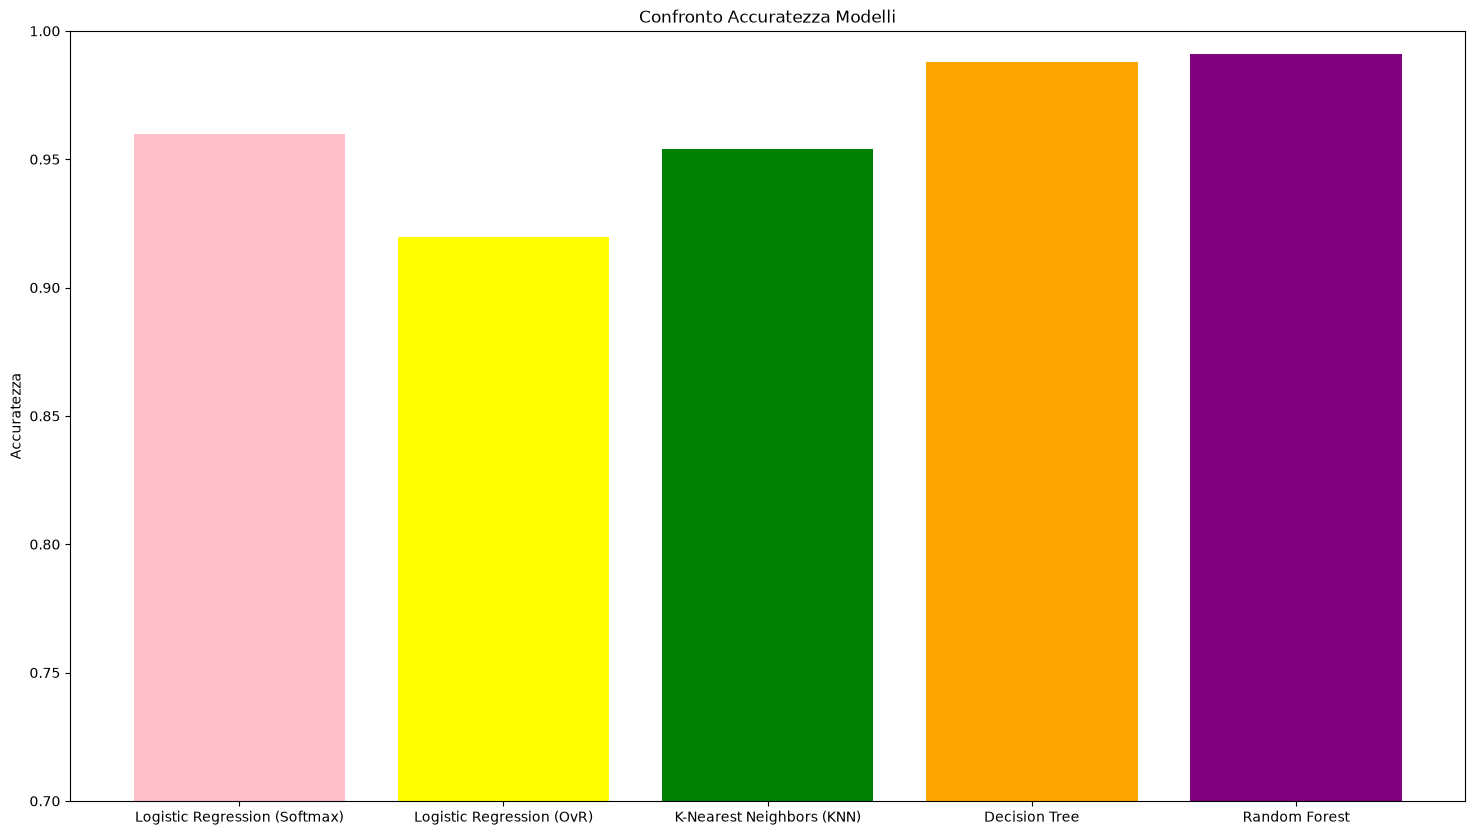

In [21]:
#definisco i modelli da mettere a confronto in un dizionario
from sklearn.multiclass import OneVsRestClassifier
models= {
    'Logistic Regression (Softmax)': LogisticRegression(max_iter=5000, random_state=42),
    'Logistic Regression (OvR)': OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced', random_state=42)),
    'K-Nearest Neighbors (KNN)': KNeighborsClassifier(),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

#adesso li addestro e li valuto
accuracies={}
conf_matrix={}
class_names=['GALAXY','QSO', 'STAR']

print('\n'+'='*60)
print('Inizio addestramento con Cross-Validation e Test')
print('='*60)

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    #Cross-Validation
    cv_scores=cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring='accuracy')
    mean_acc=cv_scores.mean()
    std_acc=cv_scores.std()

    
    model.fit(x_train_scaled,y_train) #addestro il modello

    y_hat=model.predict(x_test_scaled) #predizione

    #calcolo l'accuratezza
    acc=accuracy_score(y_test, y_hat)
    
    accuracies[name]=acc
    conf_matrix[name]=confusion_matrix(y_test, y_hat)

    print(f'Modello: {name}')
    print(f'Accuratezza CV (5-fold): {mean_acc:.4f} (+/- {std_acc:.4f})') #dato robusto
    print(f'Accuratezza Test Set: {acc:.4f}') #dato puntuale
    print('-'*60)
    print(classification_report(y_test, y_hat, target_names=class_names))

#Confronto finale e Grafico
plt.figure(figsize=(18,10))
plt.bar(accuracies.keys(), accuracies.values(), color=['pink', 'yellow', 'green', 'orange', 'purple'])
plt.title('Confronto Accuratezza Modelli')
plt.ylabel('Accuratezza')
plt.ylim(0.7, 1.0)
plt.show()


    

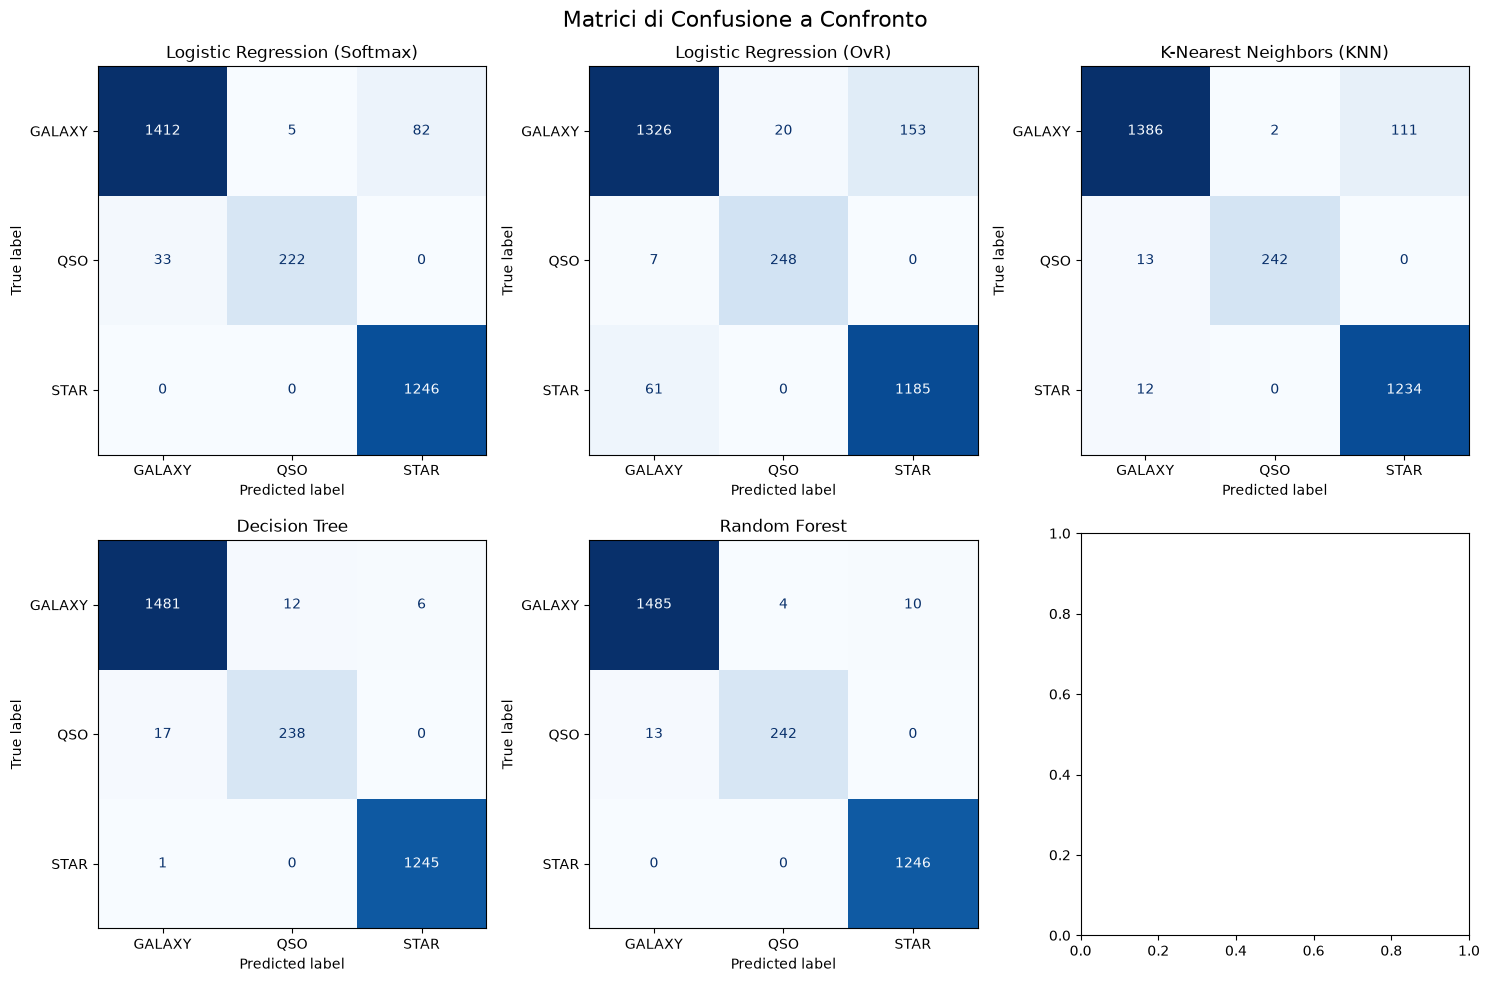

In [22]:
#matrici di confusione
fig, axes=plt.subplots(2,3, figsize=(15,10))
axes=axes.flatten()

for i, (name,cm) in enumerate(conf_matrix.items()):
    disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name)

plt.suptitle('Matrici di Confusione a Confronto', fontsize=16)
plt.tight_layout()
plt.show()

La **Regressione Logistica** ha fornito una baseline solida, con un'accuratezza globale sul test set del 96%. Tuttavia, l'analisi della classe QSO rivela i limiti strutturali del modello: con una Recall di 0.87, la regressione logistica ha mancato l'identificazione del 13% degli oggetti QSO, come si può anche osservare dalla matrice di confusione, 33 osservazioni sui Quasar sono stati erroneamente classificati come Galassie.

Questo risultato conferma ciò che era stato già osservato nel Pair Plot, ossia che la relazione tra le feature dei Quasar e quelle delle Galassie non sia puramente lineare, il bias introdotto dall'assunzione di linearità ha penalizzato la sensibilità sulla classe minoritaria.

Il **K-Nearest Neighbors** ha registrato l'accuratezza globale più bassa. Sebbene la natura non parametrica del KNN abbia permesso di catturare meglio la natura locale dei QSO, come si può osservare dal Recall salito a 0.95 e dalla matrice di confusione in cui solo 13 Quasar sono stati erroneamente classificati come Galassie, il modello ha fallito nel classificare correttamente Stelle e Galassie, questo dovuto al fatto che il KNN è sensibile al rumore nelle regioni di confine tra le classi dense, dove la regola di maggioranza locale può generare falsi positivi, come si osserva dalla matrice di confusione 111 Galassie sono state confuse con Stelle (i punti di frontiera delle Galassie sono stati probabilmente assorbiti dalla densità locale delle Stelle).

Il passaggio dai modelli lineari e basati sulla distanza al **Decision Tree** ha segnato un netto miglioramento delle capacità predittive. Il risultato più rilevante è la performance perfetta sulla classe Star, come si può vedere sia dall'F1-Score che dalla matrice di confusione. Ciò vuol dire che le stelle possiedono caratteristiche fisiche che le distinguono nettamente da Galassie e Quasar dato che l'algoritmo di *recursive binary splitting* ha individuato con successo delle regole di taglio nette. Il Decision Tree ha mostrato anche una certa robustezza nella gestione dello sbilanciamento delle classi, come si può vedere dalla matrice di confusione solo 17 Quasar sono stati erroneamnete classificati come Galassie; sebbene il numero sia leggermente superiore a quello ottenuto con il KNN, l'albero offre un bilanciamento globale superiore.

La **Random Forest** è il miglior performer in assoluto, conferma la superiorità dell'approccio ensemble, ossia conferma che l'averaging di più alberi ha ridotto la varianza senza aumentare il bias.



## Regressione Logistica Multinomiale: Softmax vs One-vs-Rest
Sebbene la libreria **scikit-learn** utilizzi l'approccio **Softmax** come standard predefinito per i problemi di classificazione multiclasse, è stato condotto un esperimento comparativo implementando la strategia **One-vs-Rest (OvR)** al fine di valutare se la scomposizione del problema in classificatori binari indipendenti possa offrire vantaggi rispetto alla modellazione congiunta.

Con l'approccio Softmax, il modello considera tutte le classi contemporaneamente, concettualmente, il modello elegge una delle classi come categoria di riferimento (*baseline*) e stima i logaritmi dei rapporti di probabilità (*log-odds*) di tutte le altre classi rispetto ad essa. La caratteristica distintiva di questo approccio è che le probabilità stimate per le $ K $ classi sono vincolate a essere mutuamente esclusive e a sommare all'unità. Ciò significa che durante l'addestramento, all'aumento della probabilità assegnata a una classe consegue la riduzione delle probabilità delle altre, permettendo al modello di catturare le relazioni competitive tra le diverse categorie.


Con l'approccio One-vs-Rest il problema multiclasse viene frammentato in $ K $ problemi di classificazione binaria indipendenti. In questo caso, vengono addestrati tre classificatori distinti, ognuno specializzato nel riconoscere una sola classe rispetto a tutto il resto del dataset:

- **Modello 1 (Stella vs Resto)**: distingue le Stelle da tutto ciò che non è una Stella;

- **Modello 2 (Galassia vs Resto)**: distingue le Galassie da tutto ciò che non è una Galassia;

- **Modello 3 (Quasar vs Resto)**: distingue i Quasar da tutto ciò che non è un Quasar;

Per classificare una nuova osservazione, questa viene sottoposta a tutti e tre i modelli contemporaneamente, ognuno di essi produce in uscita una certa probabilità e l'algoritmo assegna l'osservazione alla classe che ha ottenuto il puntegio di probabilità più alto.


Dall'analisi sperimentale si osserva che l'approcio Softmax è globalmente superiore rispetto a OvR, in quanto registra un'accuratezza sul Test set di 96.00% contro 91.97% di OvR.
Sebbene l'OvR sia globalmente meno accurato, ha mostrato una Recall nettamente superiore in corrispondenza della classe minoritaria (Quasar), identificando correttamente il 97% dei Quasar; questo guadagno è avvenuto però a scapito della precisione sulle classi maggioritarie.
Questo probabilmente è avvenuto perchè, come si osserva dall'ultima riga del pairplot, i Quasar costituiscono un gruppo separato e distinto dal resto dei dati, quindi il classificatore binario indipendente *Quasar vs Resto* è riuscito a isolare efficacemente questa classe senza subire le interferenze delle altre categorie.

Al contrario, il grafico evidenzia una significativa sovrapposizione tra le nubi di Stelle e Galassie, pertanto i classificatori *Stella vs Resto* e *Galassia vs Resto* vanno in crisi in questa zona. L'approccio Softmax, invece, eccelle in questa separazione perchè trasforma questo problema di classificazione in una competizione diretta tra categorie; imponendo che le probabilità siano mutuamente esclusive (somma unitaria), il modello penalizza le ambiguità nelle regioni di sovrapposizione, costringendo l'algoritmo a tracciare confini decisionali più netti. In particolare, il modello impara non solo "cosa assomiglia a una Stella" ma soprattutto "cosa distingue una Stella da una Galassia". 


## Inferenza statistica
Al fine di non limitare l'analisi alla sola capacità predittiva del modello, ma di comprendere quali variabili guidino le decisioni di classificazione, è stata condotta un'analisi inferenziale sui coefficienti $ \beta $ stimati dal modello di Regressione Logistica Multinomiale (Softmax).

### Bootstrap
Il Bootstrap non parametrico consente di quantificare l'incertezza delle stime campionarie senza dipendere da assunzioni stringenti sulla distribuzione teorica dei dati.
Il procedimento, eseguito su $ B=1000 $ iterazioni, si è articolato nelle seguenti fasi:

1. **Campionamento (Resampling)** : partendo dal dataset di training originale di dimensione $ n $, sono stati generati $ B $ campioni bootstrap estraendo n osservazioni con reimmissione (with replacement), cioè in ogni singolo campione di bootstrap alcune osservazioni originali possono comparire più volte mentre altre posson essere escluse;

2. **Stima dei parametri**: per ogni campione bootstrap $ b $, il modello di regressione Logistica è stato nuovamente addestrato ottenendo un nuovo set di stime per i coefficienti. Questo passaggio simula la variabilità che si otterrebbe estraendo ripetutamente campioni dalla popolazione reale;

3. **Calcolo dell'Errore Standard** : l'errore standard (SE) di ciascun coefficiente è stato stimato calcolando la deviazione standard della distribuzione dei coefficienti di bootstrap. Tale stima è stata poi utilizzata per derivare gli z-scores e i relativi p-values, testando l'ipotesi nulla che il predittore non abbia effetto sulla variabile di risposta ( $ H_0 : \beta_j = 0 $ ).


In [23]:
from scipy.stats import norm
from sklearn.utils import resample
from sklearn.base import clone

n_iterations = 1000    # Numero di iterazioni bootstrap 
log_reg = models['Logistic Regression (Softmax)'] 


#qui si fa il loop con il bootstrap
bootstrap_coefs = []

for i in range(n_iterations):
    X_res, y_res = resample(x_train, y_train, stratify=y_train, random_state=i)
    
    #clono il modello per non alterare quello originale
    model_boot = clone(log_reg)
    model_boot.fit(X_res, y_res)
    
    bootstrap_coefs.append(model_boot.coef_)

# array numpy 3D (n_iterazioni, n_classi, n_features)
bootstrap_coefs = np.array(bootstrap_coefs)


# qui calcolo le statistiche dei coefficienti di bootstrap
std_errors = bootstrap_coefs.std(axis=0)


original_coefs = log_reg.coef_ #estraggo i coefficienti del modello originale

#test
z_scores = original_coefs / (std_errors + 1e-10)

p_values = (1 - norm.cdf(np.abs(z_scores))) * 2


#creo la tabella per il confronto finale
frames = []

for i, class_name in enumerate(class_names):
   
    df_class = pd.DataFrame({
        'Coef': original_coefs[i],
        'P-Value': p_values[i]
    }, index=x_train.columns)
    
    # aggiungo asterischi: * <0.05, ** <0.01, *** <0.001
    df_class['Sig.'] = df_class['P-Value'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    )
    
    frames.append(df_class)


final_report = pd.concat(frames, axis=1, keys=class_names)


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

print('\n'+'='*100)
print('Stime dei parametri del modello di Regressione Logistica (Softmax) con i rispettivi p-values')
print('='*100)

print(final_report)


Stime dei parametri del modello di Regressione Logistica (Softmax) con i rispettivi p-values
          GALAXY                  QSO                  STAR             
            Coef P-Value Sig.    Coef P-Value Sig.     Coef P-Value Sig.
redshift  9.8372  0.0000  *** 12.8441  0.0000  *** -22.6812  0.0000  ***
PCA_1    -0.5723  0.0000  ***  0.5904  0.0000  ***  -0.0181  0.3225     
PCA_2     0.5611  0.0000  *** -0.5560  0.0000  ***  -0.0051  0.9134     


\
Dalla tabella si osserva:

1. **Il ruolo dominante del Redshift**

   la variabile redshift emerge come il discriminante più potente e statisticamente significativo trasversalmente a tutte e tre le classi, sebbene con effetti diversi: per *GALAXY* e *QSO* i coefficienti sono fortemente positivi, risultato coerente con la teoria astrofisica perchè Galassie e Quasar sono oggetti extragalattici distanti, pertanto un aumento del redshift incrementa drasticamente la log-probabilità che un oggetto appartenga a una di queste due classi; per *STAR* il coefficiente è fortemente negativo, ciò indica che valori elevati di redshift penalizzano severamente la probabilità che un oggetto sia una Stella, in altre parole, le stelle sono oggetti locali, quindi hanno basso redshift e non appena quest'ultimo aumenta, la probabilità che l'oggetto sia una Stella crolla a zero.

3. **Le componenti Principali come discriminante tra Galassie e Quasar**

   Per GALAXY e QSO entrambi le componenti PCA sono altamente significative, in particolare si osserva l'inversione sei segni. Poichè sia Galassie che Quasar hanno alti valori di redshift, questa variabile da sola non basta a distinguerli, il modello pertanto utilizza le informazioni spettrali (PCA) per separare queste due classi.


4. **La non significatività delle componenti principali per la classe STAR**

   Si osserva che le componenti PCA non sono significative per la classe STAR, inoltre i coefficienti sono circa zero. Ciò suggerisce che per classificare una Stella il modello si affida quasi esclusivamente al redshift.


Tale analisi conferma la coerenza fisica del modello: il Redshift opera una prima stratificazione macroscopica, segregando le sorenti locali (Stelle) da quelle cosmologiche. Successivamnete le componenti principali assumono un ruolo cruciale per la classificazione degli oggetti distanti (Galassie e Quasar) grazie alle sottili differenze nei loro profili spettrali.
   

### Feature Importance - Random Forest
A differenza della Regressione Logistica, che utilizza i coefficienti $ \beta $, il Random Forest stima l'importanza delle variabili calcolando la diminuzione media dell'Impurità.

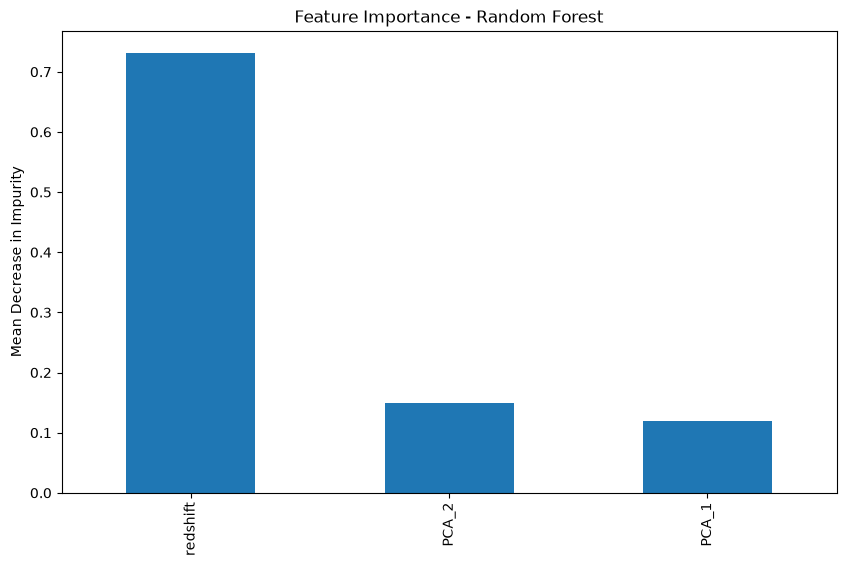

In [24]:

rf_model = models['Random Forest'] 
imp=rf_model.feature_importances_
feature_names=x_train.columns

rf_featimp=pd.Series(imp, index= feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
rf_featimp.plot.bar()
plt.title('Feature Importance - Random Forest')
plt.ylabel('Mean Decrease in Impurity')
plt.show()


Come evidenziato dal grafico a barre, la variabile redshift domina in modo schiacciante su tutte le altre feature, confermandosi il predittore principale per la classificazione.

Questo risultato è perfettamente coerente con la fisica del problema. 

Il Random Forest ha appreso che il redshift agisce come un "separatore primario" : permette di tagliare nettamente il dataset in due macro-gruppi (oggetti locali a basso redshift come le Stelle, e oggetti cosmologici ad alto redshift come Galassie e Quasar). 

La concordanza tra i risultati di Random Forest e Regressione Lineare conferma che il redshift è una proprietà intrinseca e robusta dei dati astrofisici: la distanza è la caratteristica discriminante fondamentale dell'Universo osservabile.

<p style="text-align: right;">
 
 *Elena Cascone*
</p>
